**PHASE 1 — AI SYSTEM & TRUST CONTEXT**

- Selected System: Clinical AI Diagnostic Assistant.
- User Role: Emergency Room Physician using AI to assess sepsis risk.
- Decision Criticality:
  - False negatives → death risk.
  - False positives → overtreatment, ICU overload.
- Consequences:
| Scenario    | Risk                                                  |
| ----------- | ----------------------------------------------------- |
| Over-trust  | Physician blindly follows incorrect AI recommendation |
| Under-trust | Physician ignores highly accurate AI alert            |


**PHASE 2 — CONFIDENCE SIGNALING ANALYSIS**

Current AI Signaling Problems:

| Signal Type              | Issue             | Trust Risk                    |
| ------------------------ | ----------------- | ----------------------------- |
| Probability score (0.87) | Overly precise    | Over-trust                    |
| Green/red risk label     | Binary framing    | Under-trust of moderate cases |
| Confident language       | “High likelihood” | Automation bias               |
| No uncertainty band      | Missing variance  | False certainty               |


**Phase 3: Trust Misalignment Measurement**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

Simulate AI Reliability vs Confidence

In [2]:
N = 5000

# True reliability of AI (actual accuracy distribution)
true_accuracy = np.random.beta(8, 2, N)

# AI reported confidence (slightly miscalibrated)
reported_confidence = true_accuracy + np.random.normal(0.05, 0.08, N)
reported_confidence = np.clip(reported_confidence, 0, 1)

Simulate Human Acceptance Behavior

In [3]:
def simulate_human_acceptance(confidence):
    """
    Humans accept AI recommendation
    based on perceived confidence.
    """
    return np.random.binomial(1, confidence)

human_accept = simulate_human_acceptance(reported_confidence)

Measure Trust Misalignment

- Over-Trust: Human accepts when AI is wrong.
- Under-Trust: Human rejects when AI is correct.

In [4]:
ai_correct = np.random.binomial(1, true_accuracy)

overtrust = np.sum((human_accept == 1) & (ai_correct == 0))
undertrust = np.sum((human_accept == 0) & (ai_correct == 1))

overtrust_rate = overtrust / N
undertrust_rate = undertrust / N

print("Overtrust Rate:", overtrust_rate)
print("Undertrust Rate:", undertrust_rate)

Overtrust Rate: 0.1518
Undertrust Rate: 0.1092


Trust Calibration Error Metric

Trust Calibration Error (TCE):

- TCE=∣Human Acceptance Rate−AI Accuracy∣

In [5]:
human_accept_rate = np.mean(human_accept)
ai_accuracy_rate = np.mean(ai_correct)

TCE = abs(human_accept_rate - ai_accuracy_rate)
print("Trust Calibration Error:", TCE)

Trust Calibration Error: 0.04259999999999997


Visualization

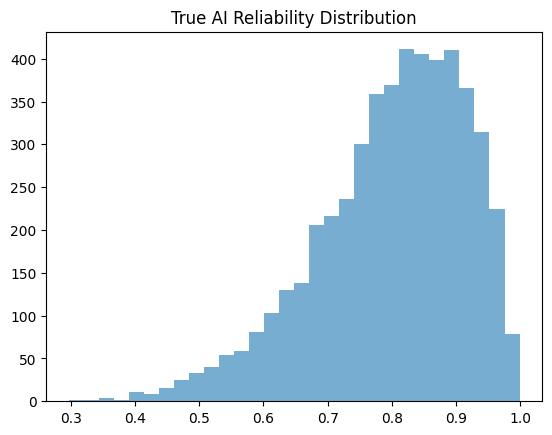

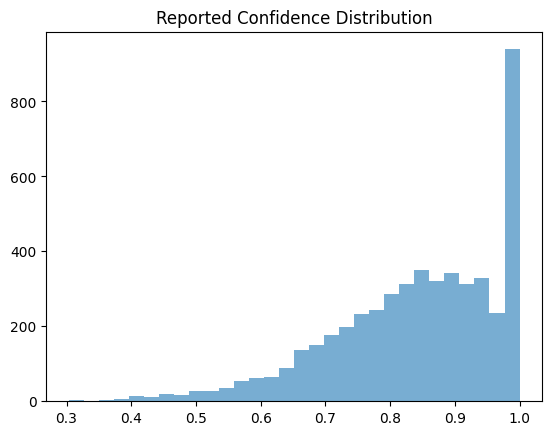

In [6]:
plt.figure()
plt.hist(true_accuracy, bins=30, alpha=0.6)
plt.title("True AI Reliability Distribution")
plt.show()

plt.figure()
plt.hist(reported_confidence, bins=30, alpha=0.6)
plt.title("Reported Confidence Distribution")
plt.show()

Automated Calibration Module

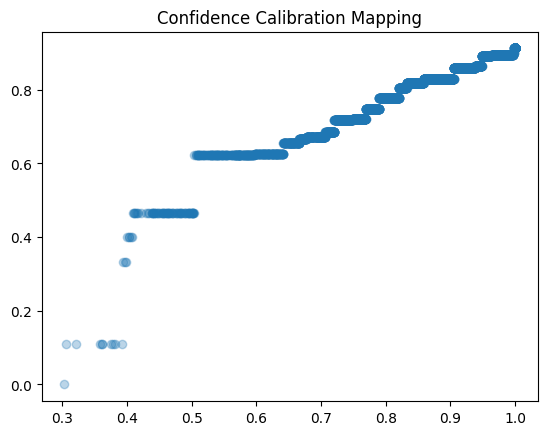

In [7]:
from sklearn.isotonic import IsotonicRegression

ir = IsotonicRegression(out_of_bounds='clip')
calibrated_confidence = ir.fit_transform(reported_confidence, ai_correct)

plt.figure()
plt.scatter(reported_confidence, calibrated_confidence, alpha=0.3)
plt.title("Confidence Calibration Mapping")
plt.show()